In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r'Hospital_Dataset Updated.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               3000 non-null   str  
 1   hospital_branch    3000 non-null   str  
 2   weekday            3000 non-null   str  
 3   total_beds         3000 non-null   int64
 4   icu_beds           3000 non-null   int64
 5   occupied_beds      3000 non-null   int64
 6   occupied_icu_beds  3000 non-null   int64
 7   available_beds     3000 non-null   int64
 8   admissions         3000 non-null   int64
 9   discharges         3000 non-null   int64
 10  emergency_cases    3000 non-null   int64
 11  staff_available    3000 non-null   int64
dtypes: int64(9), str(3)
memory usage: 281.4 KB


In [4]:
df.head(10)

,date,hospital_branch,weekday,total_beds,icu_beds,occupied_beds,occupied_icu_beds,available_beds,admissions,discharges,emergency_cases,staff_available
0,01-01-2018,Metro Hospital,Wednesday,175,31,140,25,35,40,38,18,92
1,01-02-2018,Metro Hospital,Thursday,175,31,175,21,0,69,19,26,57
2,01-03-2018,Metro Hospital,Friday,175,31,172,22,3,31,34,22,113
3,01-04-2018,Metro Hospital,Saturday,175,31,175,27,0,52,15,12,106
4,01-05-2018,Metro Hospital,Sunday,175,31,175,30,0,69,19,24,59
5,01-06-2018,Metro Hospital,Monday,175,31,175,27,0,27,23,29,98
6,01-07-2018,Metro Hospital,Tuesday,175,31,172,31,3,43,46,22,73
7,01-08-2018,Metro Hospital,Wednesday,175,31,174,31,1,24,22,33,71
8,01-09-2018,Metro Hospital,Thursday,175,31,175,31,0,63,18,11,69
9,01-10-2018,Metro Hospital,Friday,175,31,175,29,0,63,45,15,81


In [5]:
df.isnull().sum()

date                 0
hospital_branch      0
weekday              0
total_beds           0
icu_beds             0
occupied_beds        0
occupied_icu_beds    0
available_beds       0
admissions           0
discharges           0
emergency_cases      0
staff_available      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['date'] = pd.to_datetime(df['date'], format='mixed')

In [9]:
df['date'].head(13)

0    2018-01-01
1    2018-01-02
2    2018-01-03
3    2018-01-04
4    2018-01-05
5    2018-01-06
6    2018-01-07
7    2018-01-08
8    2018-01-09
9    2018-01-10
10   2018-01-11
11   2018-01-12
12   2018-01-13
Name: date, dtype: datetime64[us]

In [10]:
df = df.sort_values(by='date')

In [11]:
df['occupancy_rate'] =(df['occupied_beds'] / df['total_beds']) * 100

In [12]:
df[['occupied_beds','total_beds','occupancy_rate']].head()

,occupied_beds,total_beds,occupancy_rate
0,140,175,80.000000
1,175,175,100.000000
2,172,175,98.285714
3,175,175,100.000000
4,175,175,100.000000


In [13]:
df['icu_utilization'] = (df['occupied_icu_beds'] / df['icu_beds']) * 100

In [14]:
df[['occupied_icu_beds','icu_beds','icu_utilization']].head()

,occupied_icu_beds,icu_beds,icu_utilization
0,25,31,80.645161
1,21,31,67.741935
2,22,31,70.967742
3,27,31,87.096774
4,30,31,96.774194


In [15]:
df.head(5)

,date,hospital_branch,weekday,total_beds,icu_beds,occupied_beds,occupied_icu_beds,available_beds,admissions,discharges,emergency_cases,staff_available,occupancy_rate,icu_utilization
0,2018-01-01,Metro Hospital,Wednesday,175,31,140,25,35,40,38,18,92,80.000000,80.645161
1,2018-01-02,Metro Hospital,Thursday,175,31,175,21,0,69,19,26,57,100.000000,67.741935
2,2018-01-03,Metro Hospital,Friday,175,31,172,22,3,31,34,22,113,98.285714,70.967742
3,2018-01-04,Metro Hospital,Saturday,175,31,175,27,0,52,15,12,106,100.000000,87.096774
4,2018-01-05,Metro Hospital,Sunday,175,31,175,30,0,69,19,24,59,100.000000,96.774194


In [16]:
df['occupancy_lag_1'] = df['occupancy_rate'].shift(1)

In [17]:
df['occupancy_lag_7'] = df['occupancy_rate'].shift(7)

In [18]:
df['rolling_avg_7'] = (df['occupancy_rate'].rolling(window=7).mean())

In [19]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['hospital_branch_encoded'] = (encoder.fit_transform(df['hospital_branch']))

In [20]:
df['target_occupancy'] = (df['occupancy_rate'].shift(-1))

In [21]:
df['patient_flow'] = (df['admissions'] - df['discharges'])

In [22]:
df.dropna(inplace=True)

In [23]:
df[['occupied_beds' , 'target_occupancy']].head()

,occupied_beds,target_occupancy
7,174,100.000000
8,175,100.000000
9,175,100.000000
10,175,100.000000
11,175,95.428571


In [24]:
df.head(10)

,date,hospital_branch,weekday,total_beds,icu_beds,occupied_beds,occupied_icu_beds,available_beds,admissions,discharges,emergency_cases,staff_available,occupancy_rate,icu_utilization,occupancy_lag_1,occupancy_lag_7,rolling_avg_7,hospital_branch_encoded,target_occupancy,patient_flow
7,2018-01-08,Metro Hospital,Wednesday,175,31,174,31,1,24,22,33,71,99.428571,100.000000,98.285714,80.000000,99.428571,0,100.000000,2
8,2018-01-09,Metro Hospital,Thursday,175,31,175,31,0,63,18,11,69,100.000000,100.000000,99.428571,100.000000,99.428571,0,100.000000,45
9,2018-01-10,Metro Hospital,Friday,175,31,175,29,0,63,45,15,81,100.000000,93.548387,100.000000,98.285714,99.673469,0,100.000000,18
10,2018-01-11,Metro Hospital,Saturday,175,31,175,25,0,45,36,33,117,100.000000,80.645161,100.000000,100.000000,99.673469,0,100.000000,9
11,2018-01-12,Metro Hospital,Sunday,175,31,175,25,0,58,24,22,117,100.000000,80.645161,100.000000,100.000000,99.673469,0,95.428571,34
12,2018-01-13,Metro Hospital,Monday,175,31,167,29,8,42,50,26,54,95.428571,93.548387,100.000000,100.000000,99.020408,0,100.000000,-8
13,2018-01-14,Metro Hospital,Tuesday,175,31,175,28,0,51,28,28,89,100.000000,90.322581,95.428571,98.285714,99.265306,0,100.000000,23
14,2018-01-15,Metro Hospital,Wednesday,175,31,175,30,0,38,30,18,104,100.000000,96.774194,100.000000,99.428571,99.346939,0,97.142857,8
15,2018-01-16,Metro Hospital,Thursday,175,31,170,27,5,31,36,22,57,97.142857,87.096774,100.000000,100.000000,98.938776,0,85.142857,-5
16,2018-01-17,Metro Hospital,Friday,175,31,149,23,26,30,51,30,91,85.142857,74.193548,97.142857,100.000000,96.816327,0,100.000000,-21


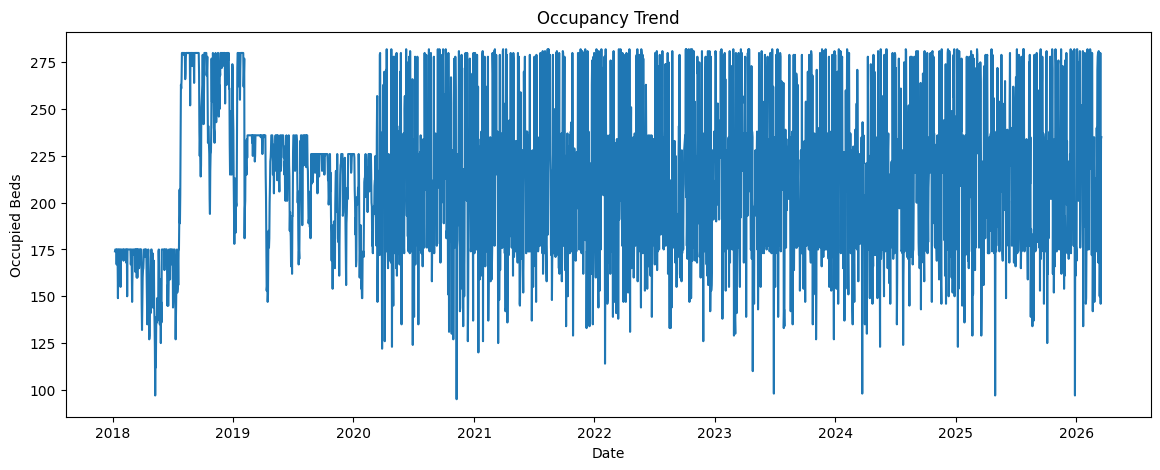

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

plt.plot(df['date'], df['occupied_beds'])

plt.title("Occupancy Trend")
plt.xlabel("Date")
plt.ylabel("Occupied Beds")

plt.show()

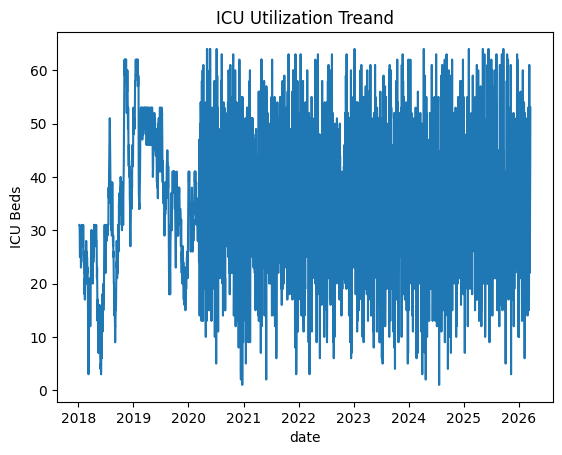

In [ ]:
plt.Figure(figsize=(14,5))
plt.plot(df['date'] , df['icu_utilization'])
plt.title("ICU Utilization Treand")
plt.xlabel("date")
plt.ylabel("ICU Beds")

plt.show()

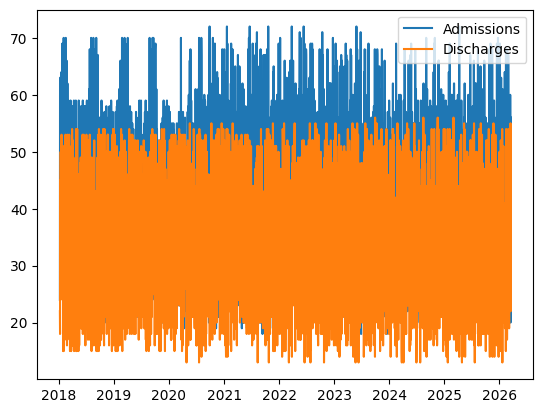

In [42]:
plt.Figure(figsize=(14,5))

plt.plot(
    df['date'], 
    df['admissions'],
    label = 'Admissions'
)

plt.plot(
    df['date'],
    df['discharges'],
    label = 'Discharges'
)

plt.legend()
plt.show()

In [45]:
features = [
    'total_beds',
    'icu_beds',
    'occupied_icu_beds',
    'admissions',
    'discharges',
    'emergency_cases',
    'staff_available',
    'occupancy_rate',
    'icu_utilization',
    'occupancy_lag_1',
    'occupancy_lag_7',
    'rolling_avg_7',
    'patient_flow',
    'hospital_branch_encoded'
]

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df[features]

y = df['target_occupancy']

x_train, x_test ,y_train,y_test = train_test_split( 
    x,
    y,
    test_size=0.2,
    shuffle=False
)

Model = LinearRegression()

Model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
prediction = Model.predict(x_test)

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test,prediction)
print('MAE : ' , mae)

r2 = r2_score(y_test,prediction)
print('R2 : ' , r2)

MAE :  7.219334049720013
R2 :  -0.05132684714067404


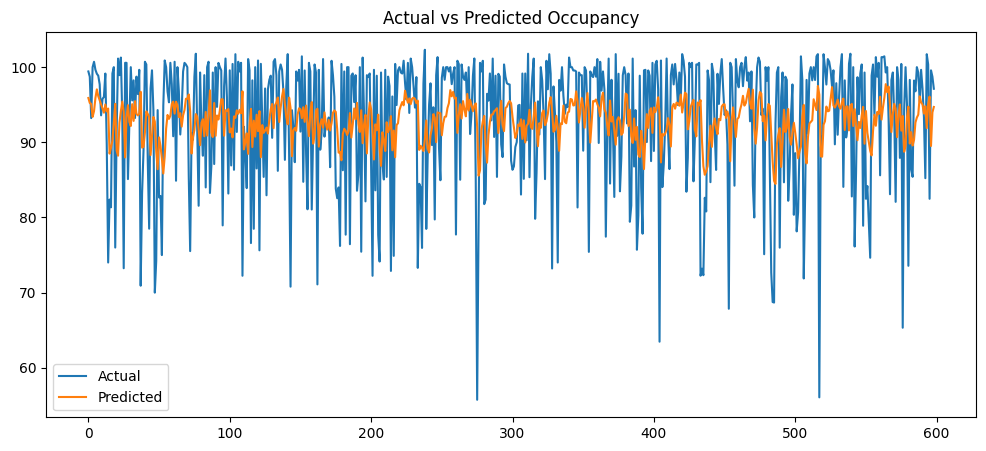

In [50]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')
plt.plot(prediction, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Occupancy")

plt.show()

In [52]:
df.to_csv("cleaned_dataset.csv",index=False)

In [53]:
df.to_csv("feature_engineered_dataset.csv",index=False)